I will now attempt to train some MobileNetV2 models and evaluate metrics. I'll be using the newly preprocessed data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import random
from tensorflow import data as tf_data
from tensorflow.keras import metrics
!pip install lime
import lime
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8323cabf33062f11bf276c706940a46b1ec1b29238c6d648b27c767875cc9aaa
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Mounted at /content/drive


In [3]:
# Set some parameters. Lower the batch size and change dimensions to (224,224)
image_size = (224, 224)
batch_size = 32
train_path = "/content/drive/MyDrive/Colab Notebooks/DATA4382_CNN_Training/preprocessed_images/train"
valid_path = "/content/drive/MyDrive/Colab Notebooks/DATA4382_CNN_Training/preprocessed_images/val"
test_path = "/content/drive/MyDrive/Colab Notebooks/DATA4382_CNN_Training/preprocessed_test"

# Train
train_ds = keras.utils.image_dataset_from_directory(
    train_path,
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode = "categorical")

# valid
val_ds = keras.utils.image_dataset_from_directory(
    valid_path,
    shuffle=False,
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode = "categorical")

# test
test_ds = keras.utils.image_dataset_from_directory(
    test_path,
    shuffle=False,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
    label_mode = "categorical")

# Get class names from the dataset and create a label map
class_names = train_ds.class_names
label_map = {name: i for i, name in enumerate(class_names)}
print(label_map)

Found 1766 files belonging to 9 classes.
Found 447 files belonging to 9 classes.
Found 144 files belonging to 9 classes.
{'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


# Naive Baseline (Only normalizing pixels)

In [4]:
# Preload batch
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

def make_transfer_model(input_shape, num_classes):
    # Load pretrained MobileNetV2 and freeze all base layers
    backbone = keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    backbone.trainable = False

    inputs = layers.Input(input_shape)

    # preprocess_input handles scaling from 0-255 to -1 to 1
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    if num_classes == 2:
        units = 1
        activation = "sigmoid"
    else:
        units = num_classes
        activation = "softmax"

    outputs = layers.Dense(units, activation=activation)(x)

    return keras.Model(inputs, outputs, name="mobilenetv2_dermoscopy")

In [5]:
baseline = make_transfer_model(input_shape=image_size + (3,), num_classes=9)
baseline.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_dermoscopy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
def training(epochs, model, train_ds, val_ds, optimizer, loss, metrics, class_weight=None):
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[metrics])

    callbacks = [keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True)]

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        class_weight=class_weight,
        callbacks=callbacks)

    return history

In [7]:
epochs = 20
optimizer = "adam"
loss='categorical_crossentropy'
f1_score_metric = keras.metrics.F1Score(average='macro', name='Macro_F1')

history_baseline = training(epochs=epochs, model=baseline, train_ds=train_ds, val_ds=val_ds, optimizer=optimizer, loss=loss, metrics=f1_score_metric)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 303s 5s/step - Macro_F1: 0.2460 - loss: 1.9747 - val_Macro_F1: 0.3741 - val_loss: 1.5630
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - Macro_F1: 0.4110 - loss: 1.5254 - val_Macro_F1: 0.3876 - val_loss: 1.4772
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - Macro_F1: 0.4457 - loss: 1.3713 - val_Macro_F1: 0.4161 - val_loss: 1.4203
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - Macro_F1: 0.4887 - loss: 1.2755 - val_Macro_F1: 0.4251 - val_loss: 1.4094
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - Macro_F1: 0.5084 - loss: 1.1812 - val_Macro_F1: 0.4440 - val_loss: 1.3524
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - Macro_F1: 0.5495 - loss: 1.1102 - val_Macro_F1: 0.4456 - val_loss: 1.3466
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - Macro_F1: 0.5473 - loss: 1.0913 - val_Macro_F1: 0.4286 - val_loss: 1.3273
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - Macro_F1: 0.5482 - loss: 1.0524 - val_Macro_F1: 0.

In [8]:
# Evaluation functions
def plot_curves(model_name, history, metric):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    metric_values = history.history[metric]
    val_metric_values = history.history[f"val_{metric}"]
    epochs = range(len(loss))

    plt.figure(figsize=(11, 3))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, metric_values, label=f"Training {metric}")
    plt.plot(epochs, val_metric_values, label=f"Validation {metric}")
    plt.title(f"{model_name} Training and Validation {metric}")
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()

    plt.tight_layout()
    plt.show()

def get_predictions(model, ds):
  y_true = []
  y_pred = []

  predictions = model.predict(val_ds)
  for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred = np.argmax(predictions, axis=1)

  return y_true, y_pred

def matrix(model, name, val_ds, class_names=None):
    y_true, y_pred = get_predictions(model, val_ds)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

def report(model, title, val_ds, class_names=None):
    y_true, y_pred = get_predictions(model, val_ds)
    print(f"{title} Classification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))

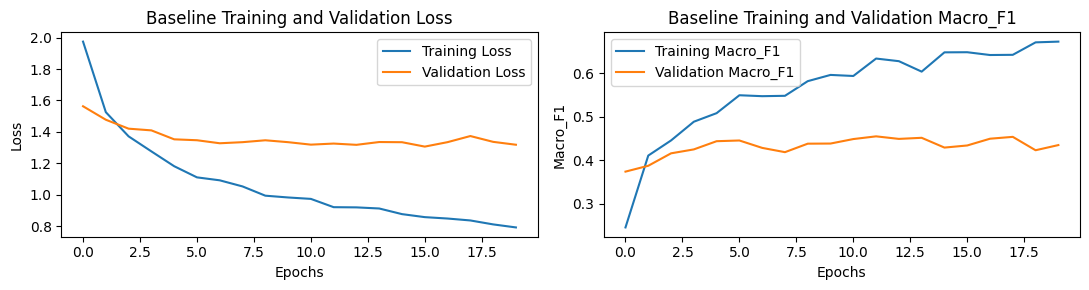

In [9]:
plot_curves("Baseline", history_baseline, metric="Macro_F1")

In [10]:
print(class_names)
abbr_class_names = ["AK", "BCC", "DF", "MEL", "NV", "PBK", "SK", "SCC", "VASC"]
print(abbr_class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
['AK', 'BCC', 'DF', 'MEL', 'NV', 'PBK', 'SK', 'SCC', 'VASC']


14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step


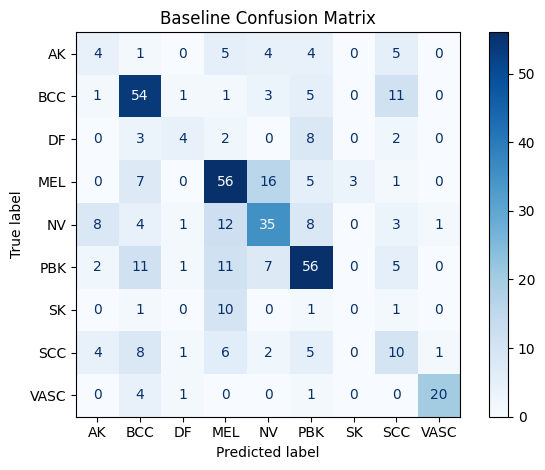

In [11]:
matrix(baseline, "Baseline", val_ds, class_names=abbr_class_names)

In [12]:
report(baseline, "Baseline", val_ds, class_names=abbr_class_names)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Baseline Classification Report
              precision    recall  f1-score   support

          AK       0.21      0.17      0.19        23
         BCC       0.58      0.71      0.64        76
          DF       0.44      0.21      0.29        19
         MEL       0.54      0.64      0.59        88
          NV       0.52      0.49      0.50        72
         PBK       0.60      0.60      0.60        93
          SK       0.00      0.00      0.00        13
         SCC       0.26      0.27      0.27        37
        VASC       0.91      0.77      0.83        26

    accuracy                           0.53       447
   macro avg       0.45      0.43      0.43       447
weighted avg       0.52      0.53      0.52       447



In [13]:
baseline.save("mobilenetv2.keras")

# Visualize Misclassified Images

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━

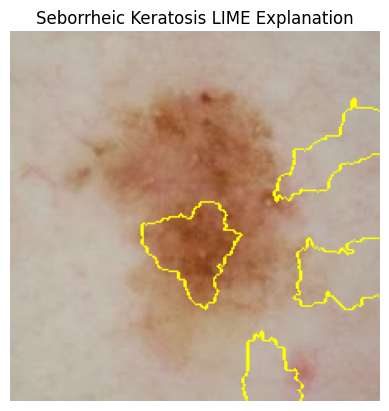

In [ ]:
explainer = lime_image.LimeImageExplainer()

sk_path = "/content/drive/MyDrive/Colab Notebooks/DATA4382_CNN_Training/sample_images/sk.jpg"
sk_img = np.array(Image.open(sk_path).resize((224, 224)))


explanation = explainer.explain_instance(
    sk_img,
    baseline.predict,
    top_labels=3,
    hide_color=0,
    num_samples=1000
)

# Visualize the explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False  # shows original image as background
)

plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.title("Seborrheic Keratosis LIME Explanation")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/s

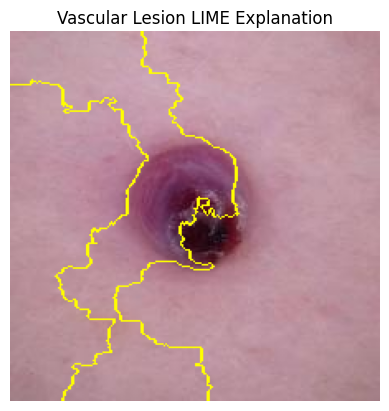

In [ ]:
explainer = lime_image.LimeImageExplainer()

vl_path = "/content/drive/MyDrive/Colab Notebooks/DATA4382_CNN_Training/sample_images/vl.jpg"
vl_img = np.array(Image.open(vl_path).resize((224, 224)))


explanation = explainer.explain_instance(
    vl_img,
    baseline.predict,
    top_labels=3,
    hide_color=0,
    num_samples=1000
)

# Visualize the explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False  # shows original image as background
)

plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.title("Vascular Lesion LIME Explanation")
plt.show()

In [ ]:
# Grad-CAM
def get_img_array(img_path, size):
    # `img` is a PIL image of size 299x299
    img = keras.utils.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.utils.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name="out_relu", pred_index=None):
    backbone = model.get_layer("mobilenetv2_1.00_224")

    # build a model that goes from input to last conv layer
    conv_model = keras.models.Model(
        inputs=backbone.inputs,
        outputs=backbone.get_layer(last_conv_layer_name).output
    )

    # build a model that goes from last conv layer to final output
    input_shape = backbone.get_layer(last_conv_layer_name).output.shape[1:]
    conv_input = layers.Input(shape=input_shape)
    x = conv_input

    found = False
    for layer in backbone.layers:
        if layer.name == last_conv_layer_name:
            found = True
            continue
        if found:
            x = layer(x)

    # continue through the rest of the full model
    x = model.get_layer("global_average_pooling2d")(x)
    x = model.get_layer("dropout")(x)
    x = model.get_layer("dense")(x)
    classifier_model = keras.models.Model(conv_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img_path, model, title, last_conv_layer_name="out_relu", alpha=0.4):
    img_array_expanded = get_img_array(img_path, size=(224, 224))
    img = keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = keras.utils.img_to_array(img)

    predictions = model.predict(img_array_expanded, verbose=0)
    pred_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions)

    heatmap = make_gradcam_heatmap(img_array_expanded, model, last_conv_layer_name)

    heatmap_rescaled = np.uint8(255 * heatmap)
    jet = mpl.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_rescaled]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img_array
    superimposed = keras.utils.array_to_img(superimposed)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original\n{title}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed)
    plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.2%})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


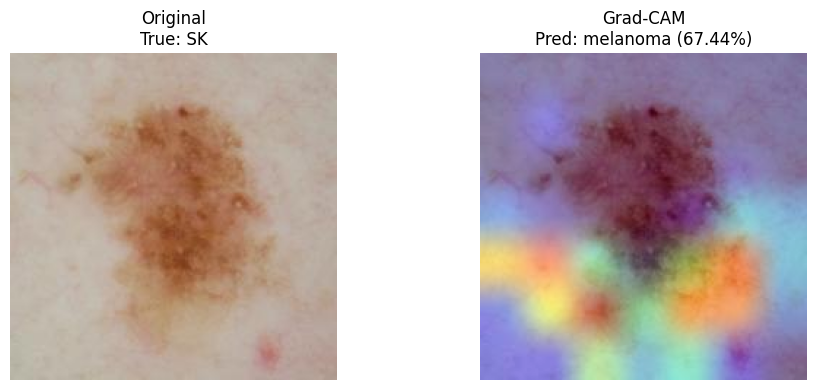

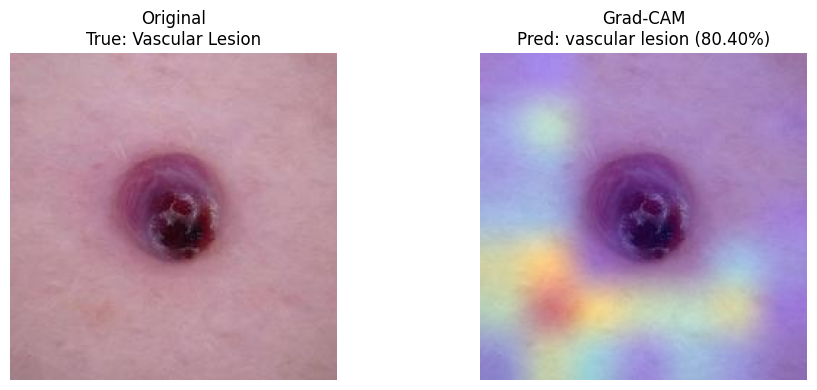

In [ ]:
display_gradcam(sk_path, baseline, "True: SK")
display_gradcam(vl_path, baseline, "True: Vascular Lesion")
